In [362]:
import pandas as pd

In [363]:
# Load attrition_past data
attrition_past = pd.read_csv('https://bradfordtuckfield.com/attrition_past.csv')

In [364]:
# Display first 3 rows
attrition_past.head(3)

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,exited
0,abcd,78,1024,12,1
1,asdf,14,2145,20,0
2,xyzz,182,3891,35,0


In [365]:
# Change the number of columns displayed to 8
pd.set_option('display.max_columns',8)

## Plotting Attrition Risk

In [366]:
# Shows percent of clients that exited their contracts in the last 6 months
print(f"{round(attrition_past['exited'].mean()*100,2)}%")

57.69%


In [367]:
import matplotlib.pyplot as plt

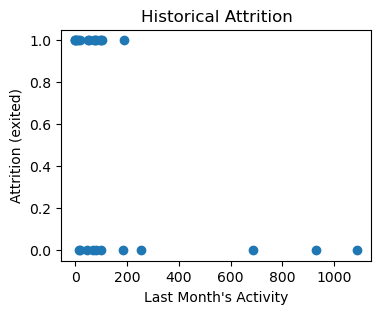

In [368]:
# Create a scatterplot of last month's activity accessing software vs customers who exited the company
fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition (exited)')
plt.show()

##### Observations: Customers who accessess the software system had not exited the company

## Confirming Relationships with Linear Regression

In [369]:
from sklearn.linear_model import LinearRegression

In [370]:
# Create X and y arrays from the attrition_past data
X = attrition_past['lastmonth_activity'].values.reshape(-1,1) # include the reshape because only 1 column used
y = attrition_past['exited']

In [371]:
# Instantiate a LinearRegression model and fit X and y
regressor = LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [372]:
# Display coefficient of linear model
regressor.coef_[0]

-0.000815028314315148

In [373]:
# Display y intercept value of linear model
regressor.intercept_

0.711935651913667

In [374]:
import matplotlib.pyplot as plt

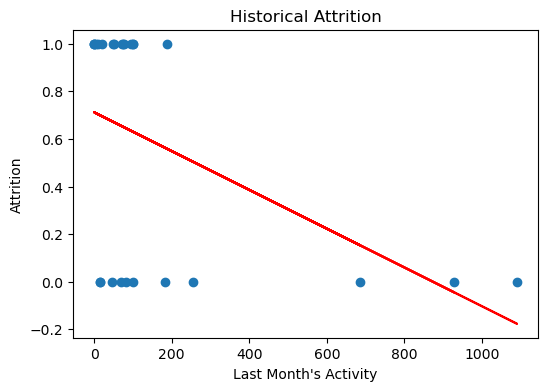

In [375]:
# create the prediction data points. The y values are a probabiliy of cancelling
prediction = [regressor.coef_[0]*x+regressor.intercept_ for x in list(attrition_past['lastmonth_activity'])]

# Create a scatterplot of actual last month activity vs exiting
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(attrition_past['lastmonth_activity'],attrition_past['exited'])

# Add a plot line of the last month activity vs the predicted exit probability 
ax.plot(attrition_past['lastmonth_activity'], prediction, color='red')
plt.title('Historical Attrition')
plt.xlabel('Last Month\'s Activity')
plt.ylabel('Attrition')
plt.show()

##### Observations: The slope of the activity to attrition is negative. The more activity that occurs, the lower the cancellation probability

In [376]:
# Display the first 5 prediction probabilities
prediction[:5]

[0.6483634433970855,
 0.700525255513255,
 0.5636004987083101,
 0.6296177921678371,
 0.711935651913667]

In [377]:
# Predict the probabilities of cancellation for the X values
# Add the prediection probability to a new column 'predicted'
attrition_past['predicted']=regressor.predict(X)

In [378]:
# Display the first 4 rows of the dataset
attrition_past.head(3)

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,exited,predicted
0,abcd,78,1024,12,1,0.648363
1,asdf,14,2145,20,0,0.700525
2,xyzz,182,3891,35,0,0.563600


## Predicting the Future

In [379]:
# Load future (new) attrition data
attrition_future = pd.read_csv('https://bradfordtuckfield.com/attrition2.csv')

In [380]:
# Display the first 5 rows
attrition_future.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees
0,hhtn,166,1393,91
1,slfm,824,16920,288
2,pryr,68,549,12
3,ahva,121,1491,16
4,dmai,4,94,2


In [381]:
# Create the X array using the last month activity
X = attrition_future['lastmonth_activity'].values.reshape(-1,1)

# Predict the probability of cancellation using the training regressor
attrition_future['predicted'] = regressor.predict(X)

In [382]:
# Display the first 5 rows
attrition_future.head(5)

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted
0,hhtn,166,1393,91,0.576641
1,slfm,824,16920,288,0.040352
2,pryr,68,549,12,0.656514
3,ahva,121,1491,16,0.613317
4,dmai,4,94,2,0.708676


##### Observations: 
 - Row 1 is very determined to not be a cancel
 - Row 0, 2, and 3 are not strong probabilities
 - Row 4 is a strong probability of cancellation

## Making business recommendations

In [383]:
# Show the top five companies with the highest predicted risk/percent of exiting
attrition_future.nlargest(5,'predicted')

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted
8,whsh,0,40,52,0.711936
12,mike,0,0,49,0.711936
24,pian,0,12,19,0.711936
21,bass,2,19,1400,0.710306
4,dmai,4,94,2,0.708676


In [384]:
# Sort corporations by their risk level of exiting
print(list(attrition_future.sort_values(by='predicted',ascending=False).loc[:,'corporation']))

['whsh', 'pian', 'mike', 'bass', 'pevc', 'dmai', 'ynus', 'kdic', 'hlpd', 'angl', 'erin', 'oscr', 'grce', 'zamk', 'hlly', 'xkcd', 'dwgt', 'pryr', 'skct', 'frgv', 'ejdc', 'ahva', 'wlcj', 'hhtn', 'slfm', 'cred']


In [385]:
# Print a list of companies with a risk level of exiting greater than 70%
print(list(attrition_future.loc[attrition_future['predicted'] > 0.7,'corporation']))

['dmai', 'whsh', 'oscr', 'kdic', 'mike', 'pevc', 'erin', 'angl', 'bass', 'ynus', 'pian', 'hlpd']


## Measuring Prediction Accuracy

In [386]:
# Calculate the median predicted probabilities in attrition_past
themedian = attrition_past['predicted'].median()

# Rows with a predicted probability greater than the median will be a True/False result that will then translate into a predicted 1 or 0 value
prediction = list(1*(attrition_past['predicted']>themedian))

# Get the actual exited values (1 or 0) 
actual=list(attrition_past['exited'])

In [387]:
# Display the median value
themedian

0.6524385849686611

##### Observation: records with a predicted probability greater than 0.6524 will be expected to cancel

In [388]:
from sklearn.metrics import confusion_matrix

In [389]:
# Create a confusion matrix of the predicted and actual exited values
print(confusion_matrix(actual, prediction))

[[7 4]
 [6 9]]


In [390]:
conf_mat = confusion_matrix(actual,prediction)
precision = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[1][0])
recall = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[0][1])

In [391]:
print(f"Precision: {round(precision,2)}")
print(f"Recall: {round(recall,2)}")

Precision: 0.54
Recall: 0.64


In [392]:
# Create the precision and recall scores using sklearn.metrics
from sklearn.metrics import recall_score, precision_score
print(f"Precision: {precision_score(actual, prediction, pos_label=0):.2f}") # used the pos_label=0 because 0 is the cancel
print(f"Recall: {recall_score(actual, prediction, pos_label=0):.2f}")

Precision: 0.54
Recall: 0.64


##### Observations:
 - The precision for manually calculated and sklearn.metrics is the same at 54%
 - The recall for manually calculated and sklearn.metrics is the same at 64%

## Using Multivariate LPMs

In [393]:
X3 = attrition_past.loc[:,['lastmonth_activity','lastyear_activity','number_of_employees']].values.reshape(-1,3)
y = attrition_past['exited'].values.reshape(-1,1)
regressor_multi = LinearRegression()
regressor_multi.fit(X3,y)

LinearRegression()

In [394]:
attrition_future['predicted_multi'] = regressor_multi.predict(X3)

In [395]:
# show the top five companies with the highest predicted risk/percent of exiting
attrition_future.nlargest(5,'predicted_multi')

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted,predicted_multi
11,ejdc,95,1005,61,0.634508,0.870000
12,mike,0,0,49,0.711936,0.815677
13,pevc,4,6,1686,0.708676,0.788110
4,dmai,4,94,2,0.708676,0.755625
22,ynus,9,90,12,0.704600,0.715362


In [396]:
# Code the future multivariate linear regression model my way
X3_mine = attrition_past.drop(['corporation','exited','predicted'], axis=1)
y = attrition_past['exited']
regressor_multi_mine = LinearRegression().fit(X3_mine, y)
attrition_future['predicted_multi']= regressor_multi_mine.predict(X3_mine)
attrition_future.nlargest(5, 'predicted_multi')

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted,predicted_multi
11,ejdc,95,1005,61,0.634508,0.870000
12,mike,0,0,49,0.711936,0.815677
13,pevc,4,6,1686,0.708676,0.788110
4,dmai,4,94,2,0.708676,0.755625
22,ynus,9,90,12,0.704600,0.715362


##### Observations: The predicted exited future values using multivariates is higher than using one variate

In [397]:
# sort corporations by their risk level of exiting
# include the probability value
print(attrition_future.sort_values(by='predicted_multi',ascending=False).loc[:,['corporation','predicted_multi']])

   corporation  predicted_multi
11        ejdc         0.870000
12        mike         0.815677
13        pevc         0.788110
4         dmai         0.755625
22        ynus         0.715362
20        wlcj         0.704097
17        angl         0.688824
24        pian         0.686465
1         slfm         0.678542
25        hlpd         0.662518
6         frgv         0.654117
23        hlly         0.647090
9         oscr         0.633874
16        cred         0.630456
19        dwgt         0.629569
0         hhtn         0.613322
8         whsh         0.603854
7         grce         0.578968
2         pryr         0.570637
15        xkcd         0.566450
21        bass         0.539072
3         ahva         0.514784
14        erin         0.442162
18        zamk         0.333600
5         skct        -0.105340
10        kdic        -0.217836


## Creating New Metrics

In [398]:
# Create a new feature call 'activity per employee'
attrition_future['activity_per_employee']= attrition_future.loc[:,'lastmonth_activity']/attrition_future.loc[:,'number_of_employees']  

In [399]:
attrition_future.head()

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted,predicted_multi,activity_per_employee
0,hhtn,166,1393,91,0.576641,0.613322,1.824176
1,slfm,824,16920,288,0.040352,0.678542,2.861111
2,pryr,68,549,12,0.656514,0.570637,5.666667
3,ahva,121,1491,16,0.613317,0.514784,7.562500
4,dmai,4,94,2,0.708676,0.755625,2.000000


In [400]:
# Use attrition_past to build a model that will be used to predict attrition_future
attrition_past['activity_per_employee'] = attrition_past['lastmonth_activity']/attrition_past['number_of_employees']
X = attrition_past[['activity_per_employee','lastmonth_activity','lastyear_activity','number_of_employees']]
y=attrition_past['exited']
regressor_derived=LinearRegression().fit(X,y)

In [401]:
attrition_past['predicted_ape']=regressor_derived.predict(X)

In [402]:
# Use the model based on the past to predict the future
X = attrition_future[['activity_per_employee','lastmonth_activity','lastyear_activity','number_of_employees']]
attrition_future['predicted_ape']=regressor_derived.predict(X)

In [403]:
# Drop the activity_per_employee feature
attrition_future.drop(['activity_per_employee'], axis=1, inplace=True)

In [404]:
# CHange the column display to 10
pd.set_option('display.max_columns',10)

In [405]:
# Display the first 3 rows
attrition_future.head(3)

,corporation,lastmonth_activity,lastyear_activity,number_of_employees,predicted,predicted_multi,predicted_ape
0,hhtn,166,1393,91,0.576641,0.613322,0.740311
1,slfm,824,16920,288,0.040352,0.678542,0.624450
2,pryr,68,549,12,0.656514,0.570637,0.620251


In [406]:
# Sort corporations by their risk level of exiting
print(list(attrition_future.sort_values(by='predicted_ape',ascending=False).loc[:,'corporation']))

['pevc', 'bass', 'frgv', 'hlpd', 'angl', 'oscr', 'zamk', 'whsh', 'mike', 'hhtn', 'ejdc', 'grce', 'pian', 'ynus', 'dmai', 'kdic', 'erin', 'slfm', 'dwgt', 'pryr', 'hlly', 'xkcd', 'skct', 'ahva', 'wlcj', 'cred']


In [412]:
# Calculate the median predicted_ape value
themedian = attrition_past['predicted_ape'].median()
# Based on the median value, set the 0/1 values for calssification for prediction
prediction = list(1*(attrition_past['predicted_ape']>themedian))
actual = list(attrition_past['exited'])

In [413]:
# create confusion matrix of the past prediction vs past actuals
print(confusion_matrix(prediction, actual))

[[ 9  4]
 [ 2 11]]


In [418]:
# Calculate the precision and recall metrics
conf_mat = confusion_matrix(prediction,actual)
precision = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[0][1])
recall = conf_mat[0][0]/(conf_mat[0][0]+conf_mat[1][0])
print(round(precision,2))
print(round(recall,2))

0.69
0.82


In [419]:
# Create the precision and recall scores using sklearn.metrics
from sklearn.metrics import recall_score, precision_score
print(f"Precision: {precision_score(actual, prediction, pos_label=0):.2f}") # used the pos_label=0 because 0 is the cancel
print(f"Recall: {recall_score(actual, prediction, pos_label=0):.2f}")

Precision: 0.69
Recall: 0.82


##### Observations: Using feature engineering and multiple variates has resulted in higher precision and recall scores

## Predicting Binary Outcomes with Logistic Regression

In [420]:
import matplotlib.pyplot as plt
import numpy as np
import math

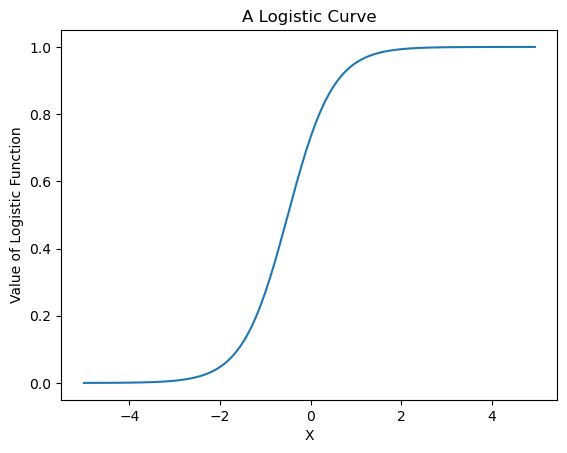

In [421]:
# Create a logistic curve manually
x = np.arange(-5,5,0.05)
y = (1/(1+np.exp(-1-2*x)))
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Value of Logistic Function")
plt.title("A Logistic Curve")
plt.show()

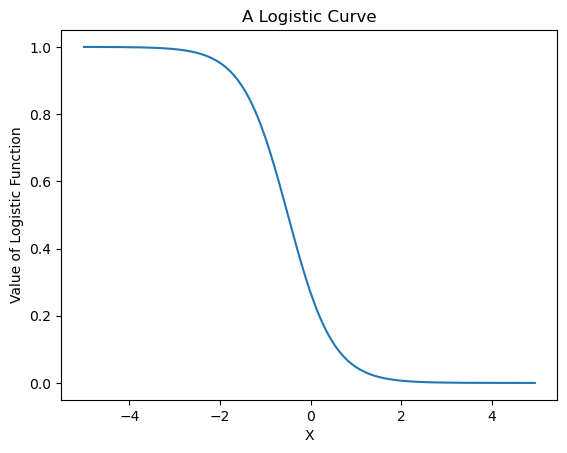

In [427]:
# Create another logistic curve manually
x = np.arange(-5,5,0.05)
y = (1/(1+np.exp(1+2*x)))
plt.plot(x,y)
plt.xlabel("X")
plt.ylabel("Value of Logistic Function")
plt.title("A Logistic Curve")
plt.show()

## Fitting the Logistic Function To Our Data

In [423]:
from sklearn.linear_model import LogisticRegression

In [424]:
# Create the X,y and fit the data to a LogisticRegression model
X = attrition_past['lastmonth_activity'].values.reshape(-1,1)
y = attrition_past['exited']
model = LogisticRegression(solver='liblinear', random_state=0)
model.fit(X,y)

LogisticRegression(random_state=0, solver='liblinear')

In [425]:
# Get the predicted probabilities for X
attrition_past['logisticprediction'] = model.predict_proba(X)[:,1]

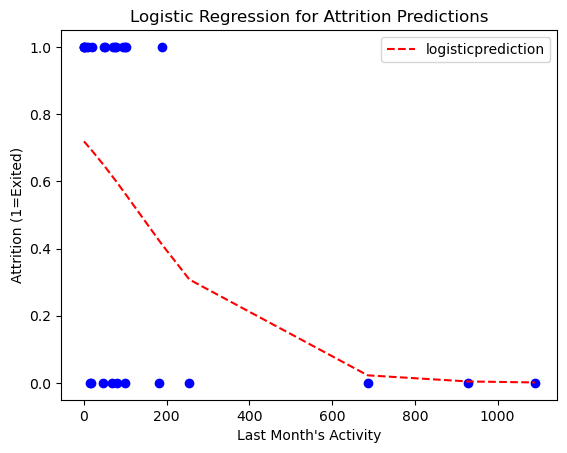

In [426]:
# Create a scatterplot of the last month activity vs the exited values
fig = plt.scatter(attrition_past['lastmonth_activity'],
                  attrition_past['exited'], color='blue')

# Create a line plot of the last month activity vs the logistic prediction
attrition_past.sort_values('lastmonth_activity').plot('lastmonth_activity',\
                                                     'logisticprediction',ls='--', ax=fig.axes, color='red')
plt.title("Logistic Regression for Attrition Predictions")
plt.xlabel("Last Month\'s Activity")
plt.ylabel("Attrition (1=Exited)")
plt.show()

##### Observations: 
 - The S curve above is the lower portion of the curve
 - The probabilities do not go above 1 or below 0

In [428]:
# List the companies in order of highest probability of cancellation
X = attrition_future['lastmonth_activity'].values.reshape(-1,1)
attrition_future['logisticprediction'] = model.predict_proba(X)[:,1]
print(list(attrition_future.sort_values(by='logisticprediction', ascending=False).loc[:,'corporation']))

['whsh', 'pian', 'mike', 'bass', 'pevc', 'dmai', 'ynus', 'kdic', 'hlpd', 'angl', 'erin', 'oscr', 'grce', 'zamk', 'hlly', 'xkcd', 'dwgt', 'pryr', 'skct', 'frgv', 'ejdc', 'ahva', 'wlcj', 'hhtn', 'slfm', 'cred']
